## Examples and Other Stats on SoilNet Inference

In [1]:
import os
os.chdir('../../../')
!pwd

/mnt/KInsektDaten/teo


In [2]:
import sys
sys.path.append('./BGR')
import numpy as np
import torch
import pickle
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn
from sklearn.metrics import precision_score, recall_score
from scipy.stats import linregress

from bgr.soil.data.horizon_tabular_data import HorizonDataProcessor
from bgr.soil.modelling.soilnet import SoilNet_LSTM
from bgr.soil.data.datasets import ImageTabularEnd2EndDataset
from bgr.soil.metrics import depth_iou
import bgr.soil.conformal as bgr_conform

In [3]:
dataprocessor = HorizonDataProcessor(label_embeddings_path='./BGR/label_embeddings/all_horizons_embeddings_thirds.pickle')
df = dataprocessor.load_processed_data()

train_df, val_df, test_df = dataprocessor.multi_label_stratified_shuffle_split(df, train_val_test_frac=[0.6, 0.2, 0.2], random_state=2025)

In [4]:
#soilnet_path = './BGR/models/end2ends/linear_decreasing_teacher/end2end_lstm_resnet_embed_2025-05-13_12-14-11/model.pt'
soilnet_path = './BGR/models/end2ends/linear_decreasing_teacher/end2end_lstm_resnet_2025-05-13_18-05-30/model.pt'
#soilnet_path = './BGR/models/end2ends/linear_decreasing_teacher/end2end_lstm_2025-05-13_12-13-14/model.pt'
output_shape = np.shape(dataprocessor.embeddings_dict['embedding']) # dimension of embeddings or number of classes
device = 'cuda:0'

In [5]:
soilnet = SoilNet_LSTM(
    # Parameters for image encoder, geotemp encoder and depth predictor:
    geo_temp_input_dim        = len(dataprocessor.geotemp_img_infos) - 2, # without index and img path
    geo_temp_output_dim       = 256,
    image_encoder_output_dim  = 512,
    max_seq_len               = 8,
    stop_token                = 1.0,
    depth_rnn_hidden_dim      = 256,
    img_patch_size            = 512,
    segments_random_patches   = True if 'resnet' in soilnet_path else False, # True = use ResNet, False = use custom CNN
    num_patches_per_segment   = 8,
    segment_random_patch_size = 224,
    
    # Parameters for tabular predictors:
    tabular_output_dim_dict    = dataprocessor.tabulars_output_dim_dict,
    segment_encoder_output_dim = 512,
    tab_rnn_hidden_dim         = 1024,
    tab_num_lstm_layers        = 2,
    
    # Parameters for horizon predictor:
    segments_tabular_output_dim = 256,
    embedding_dim               = output_shape[1] if 'embed' in soilnet_path else output_shape[0],
    
    # Parameters for the model:
    teacher_forcing_stop_epoch  = -1, # no teacher forcing when doing only inference
    teacher_forcing_approach    = 'linear'
)

soilnet.load_state_dict(torch.load(soilnet_path, map_location=torch.device(device)))

<All keys matched successfully>

In [6]:
test_dataset = ImageTabularEnd2EndDataset(
    dataframe=test_df,
    normalize=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Normalize with ImageNet statistics
        ]),
    label_column='Horizontsymbol_relevant',
    geotemp_columns=dataprocessor.geotemp_img_infos[:-1], # without img path
    tab_num_columns=['Steine'],
    tab_categ_columns={key : value 
            for key, value in dataprocessor.tabulars_output_dim_dict.items() 
                if key in [
                        'Bodenart',
                        'Bodenfarbe',
                        'Karbonat',
                        'Humusgehaltsklasse',
                        'Durchwurzelung'
                    ]
        }
)

In [7]:
batch_size = 8
test_loader  = test_dataset.to_dataloader(batch_size = batch_size,  shuffle = False, num_workers = 4)

In [ ]:
# Inference on the test set (Tasks 1 and 3)
segment_geotemp_features_test, all_pred_depths_test, \
    all_true_depths_test, all_pred_logits_test, all_true_hor_inds_test = bgr_conform.soilnet_inference(test_loader, soilnet, device)

### Visualize Predictions

In [ ]:
# Concatenattions/Aggregations
all_true_depths_test = np.concatenate(all_true_depths_test, axis=0)
all_pred_depths_test = np.concatenate(all_pred_depths_test, axis=0)

segment_geotemp_list_test = [item for sublist in segment_geotemp_features_test for item in sublist]
trimmed_true_depths_stacked_test, \
    trimmed_pred_depths_stacked_test, \
        segment_geotemp_concat_test   = bgr_conform.trim_concat(all_true_depths_test, all_pred_depths_test, segment_geotemp_list_test)

all_true_hor_inds_test = torch.from_numpy(np.concatenate(all_true_hor_inds_test, axis=0))
all_pred_logits_test = torch.from_numpy(np.concatenate(all_pred_logits_test, axis=0))
all_pred_hor_inds_test = np.argmax(all_pred_logits_test, axis=1)

In [ ]:
ex_ind = 8

# Get index of the stop token of the chosen example
stop_token_occurrences = (trimmed_true_depths_stacked_test == 1.0).nonzero(as_tuple=True)[0]
top_ind, bottom_ind = stop_token_occurrences[ex_ind-1]+1 if ex_ind > 0 else 0, stop_token_occurrences[ex_ind]+1
print(top_ind, bottom_ind)

# Retrieve image from batched dataloader
ex_num_batches = ex_ind // batch_size
ex_samples_last_batch = ex_ind % batch_size
for i, batch in enumerate(test_loader):
    if i == ex_num_batches:
        padded_images, image_masks, _, _, _, _ = batch
        padded_image, image_mask = padded_images[ex_samples_last_batch].to(device), image_masks[ex_samples_last_batch].to(device)
        break

# Unpad image
_, row_inds, col_inds = np.where(image_mask.cpu().numpy() == True)
row_ind, col_ind = max(row_inds), max(col_inds)
orig_img = padded_image[:, :row_ind, :col_ind]
print(orig_img.shape)

img_height = orig_img.shape[1]; img_width = orig_img.shape[0]
eps = 0.001
mean = torch.tensor([0.485, 0.456, 0.406], device=device) # denormalize image
std  = torch.tensor([0.229, 0.224, 0.225], device=device) 
orig_img = orig_img * std[:, None, None] + mean[:, None, None]
orig_img = orig_img.permute(1, 2, 0).cpu().numpy()

tensor(31) tensor(36)
torch.Size([3, 4299, 2864])


In [47]:
trimmed_pred_depths_stacked_test[top_ind:bottom_ind]

tensor([0.2344, 0.5276, 0.8197, 1.0000, 1.0000])

In [48]:
trimmed_true_depths_stacked_test[top_ind:bottom_ind]

tensor([0.2000, 0.4000, 0.8200, 0.9800, 1.0000])

In [49]:
all_true_hor_inds_test[top_ind:bottom_ind]

tensor([22, 22,  1, 48, 48])

In [50]:
all_pred_hor_inds_test[top_ind:bottom_ind]

tensor([22, 22, 48, 48,  0])

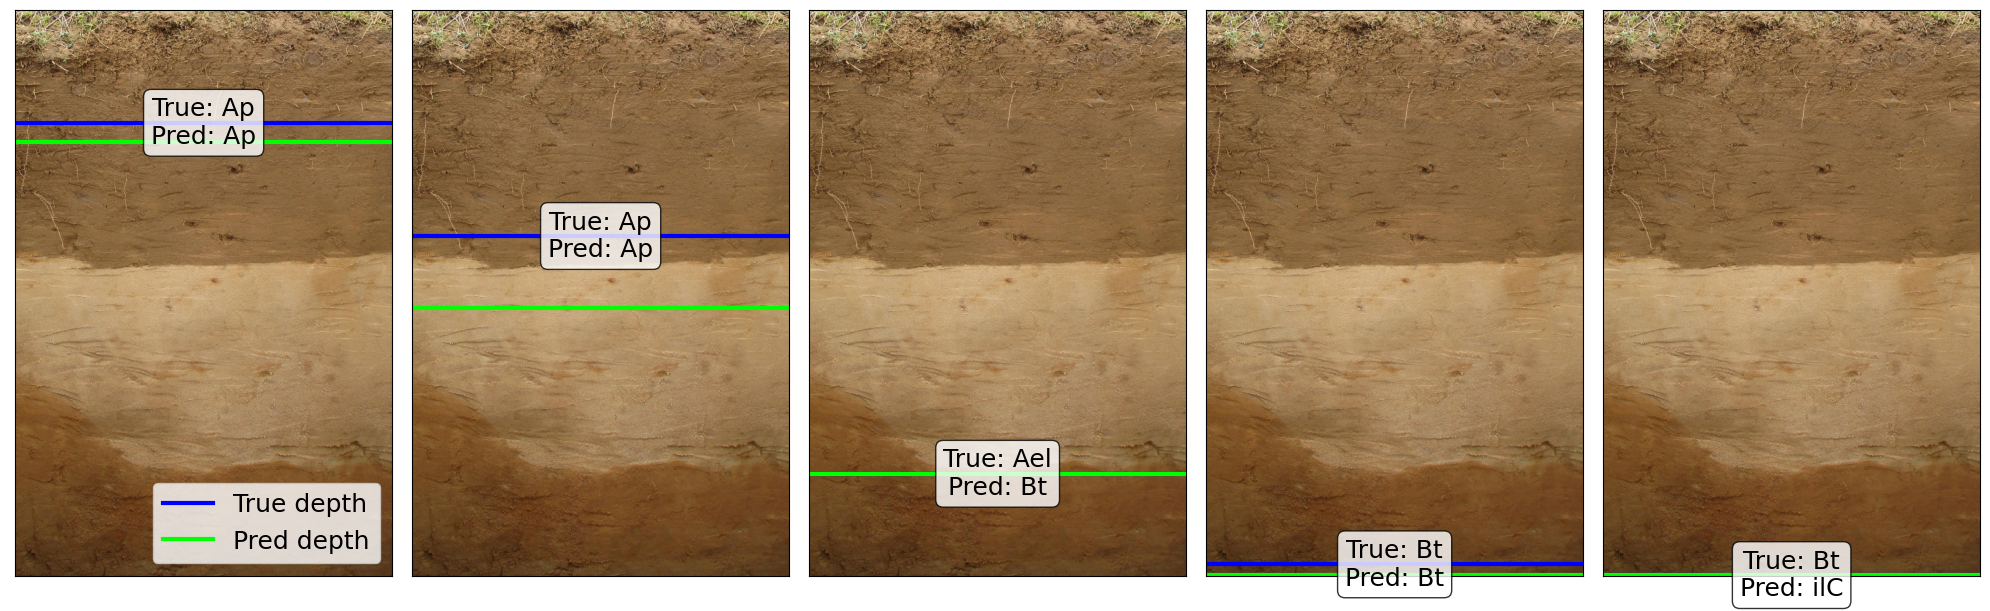

In [60]:
# Plot true and predicted depths, as well as true and predicted horizon labels
fsize = 18
plt.figure(figsize=(20, 14))
for i, ind in enumerate(range(top_ind, bottom_ind)):
    plt.subplot(1, (bottom_ind-top_ind).tolist(), i+1)
    plt.imshow(orig_img)
    
    pred_depth = np.min((trimmed_pred_depths_stacked_test[ind], 1.0-eps)) # subtract an epsilon here to avoid plot artifacts at the final prediction
    true_depth = np.min((trimmed_true_depths_stacked_test[ind], 1.0-eps))
    pred_hor_ind, true_hor_ind = all_pred_hor_inds_test[ind], all_true_hor_inds_test[ind]
    pred_hor_label, true_hor_label = dataprocessor.embeddings_dict['ind2label'][pred_hor_ind], dataprocessor.embeddings_dict['ind2label'][true_hor_ind]

    # Convert normalized depths to pixel coordinates
    plt.axhline(y=true_depth * img_height, color='blue', linestyle='-', linewidth=3)
    plt.axhline(y=pred_depth * img_height, color='lime', linestyle='-', linewidth=3)

    # Show true and predicted horizon labels
    text_x = img_width / 3
    text_y = true_depth * img_height - 0.1
    plt.text(text_x, text_y, f'True: {true_hor_label}\nPred: {pred_hor_label}', 
             ha='center', va='center', fontsize=fsize, 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    if i == 0: plt.legend(['True depth', 'Pred depth'], loc='lower right', fontsize=fsize)
    plt.xticks([]);plt.yticks([])
plt.tight_layout()
#plt.savefig('./BGR/figures/ex_predictions.pdf')
plt.show()

### Check Geological Consistency

1. Does Ap generally occur at the top of the profile?
2. How often are A-horizons detected below B or C?

In [78]:
# All predicted labels
all_pred_hor_labels_test = [dataprocessor.embeddings_dict['ind2label'][i] for i in all_pred_hor_inds_test]
#all_pred_hor_labels_test

In [85]:
# Split labels into profiles
horizons_per_profile = []
for i in range(len(stop_token_occurrences)):
    if i == 0:
        horizons_per_profile.append(all_pred_hor_labels_test[ : stop_token_occurrences[i]+1])
    else:
        horizons_per_profile.append(all_pred_hor_labels_test[stop_token_occurrences[i-1]+1 : stop_token_occurrences[i]+1])
horizons_per_profile[:5]

[['Ap', 'Ap', 'Bv', 'ilC', 'ilC', 'ilC'],
 ['Ap', 'Ap', 'Bv', 'ilC'],
 ['Ap', 'Ap', 'Sd', 'Sd'],
 ['Ap', 'Ap', 'elC'],
 ['Ap', 'Ap', 'Bt', 'elC']]

In [80]:
# How often do Ap horizons appear at the top when present?
ap_consistency_stats = {
    'profiles_with_ap': 0,
    'ap_at_beginning': 0
}

for i, profile in enumerate(horizons_per_profile):
    
    # Check if 'Ap' is in the profile
    if 'Ap' in profile:
        ap_consistency_stats['profiles_with_ap'] += 1
        
        # Check if 'Ap' appears at the beginning (first position)
        if profile[0] == 'Ap':
            ap_consistency_stats['ap_at_beginning'] += 1

# Calculate percentages
consistency_rate = (ap_consistency_stats['ap_at_beginning'] / 
                    ap_consistency_stats['profiles_with_ap']) * 100

print(f"Ap consistency rate: {consistency_rate:.2f}%")

Ap consistency rate: 86.31%


In [83]:
# A-horizons should not appear after B or C horizons
abc_consistency_stats = {
    'total_profiles_bc': 0,
    'total_violations': 0
}

for i, profile in enumerate(horizons_per_profile):
    
    # Track if we've seen a B or C horizon
    seen_b_or_c = False
    profile_violations = []
    
    for j, horizon in enumerate(profile):
        # Check if current horizon contains 'B' or 'C'
        if 'B' in horizon or 'C' in horizon:
            seen_b_or_c = True
            abc_consistency_stats['total_profiles_bc'] += 1
        
        # Check if current horizon contains 'A' and we've already seen B or C
        elif 'A' in horizon and seen_b_or_c:
            abc_consistency_stats['total_violations'] += 1

# Calculate consistency rate
if abc_consistency_stats['total_violations'] > 0:
    geological_inconsistency_rate = (abc_consistency_stats['total_violations'] / abc_consistency_stats['total_profiles_bc']) * 100
else:
    geological_inconsistency_rate = 0

print(f"Total profiles: {len(horizons_per_profile)}")
print(f"Total profiles containing B or C: {abc_consistency_stats['total_profiles_bc']}")
print(f"A after B/C violation rate: {geological_inconsistency_rate:.2f}%")

Total profiles: 670
Total profiles containing B or C: 658
A after B/C violation rate: 0.00%
